# Heart Disease Classification — Under-Sampling

## Student Practice + Complete Solution

This notebook contains **questions first and solutions immediately after each question** so students can understand what to do and then check the answer.

### Dataset
`heart_balanced.csv`

### Target
`target`

### Workflow
**Load Data → Remove Duplicates → X/y → Train/Test Split → Under-Sampling → Train Models → Evaluate → Confusion Matrix**


# Part 1 — Import Libraries

### Question 1
Import the libraries needed for:
- Data handling
- Visualization
- Train/test split
- Preprocessing
- Machine learning models
- Model evaluation

### Solution


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Part 2 — Load and Inspect the Data

### Question 2
Load `heart_balanced.csv` and display:
1. Number of rows and columns
2. First five rows
3. Number of duplicate rows

### Solution


In [13]:
df = pd.read_csv("heart_balanced.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nNumber of duplicate rows:", df.duplicated().sum())


Dataset shape: (20000, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,37,1,2,130,249,0,1,187,0,3.50,0,0,2,1
1,77,1,0,125,305,0,0,162,1,-0.01,2,3,2,0
2,63,0,0,150,408,0,0,153,0,4.00,1,3,3,0
3,65,0,0,150,224,0,0,114,0,0.99,1,3,3,0
4,53,1,2,130,246,1,0,173,0,-0.00,2,3,2,1



Number of duplicate rows: 6447


# Part 3 — Remove Duplicate Rows

### Question 3
Remove all exact duplicate rows and check the new shape.

### Solution


In [14]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())


Shape after removing duplicates: (13553, 14)
Remaining duplicates: 0


# Part 4 — Separate Features and Target

### Question 4
Create:
- `X` = input features
- `y` = target column

### Solution


In [15]:
target_col = "target"

X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())


X shape: (13553, 13)
y shape: (13553,)

Target distribution:
target
0    7291
1    6262
Name: count, dtype: int64


# Part 5 — Train/Test Split

### Question 5
Split the dataset into:
- 80% training data
- 20% testing data

Use `stratify=y`.

### Why?
We want the model to learn from training data and evaluate it on data it has never seen.

### Solution


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 10842
Testing rows: 2711


# Part 6 — Prepare the Features

### Question 6
Find numeric and categorical columns.

Then prepare missing values and categorical values so machine learning models can use them.

### Solution


In [17]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)




Numeric columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Categorical columns: []


In [18]:
preprocessor = ColumnTransformer([
    ("numeric",
     SimpleImputer(strategy="median"),
     numeric_cols),

    ("categorical",
     Pipeline([
         ("imputer", SimpleImputer(strategy="most_frequent")),
         ("onehot", OneHotEncoder(handle_unknown="ignore"))
     ]),
     categorical_cols)
])

# Part 7 — Under-Sampling

### Question 7
Apply the correct **under-sampling** technique.

### Explanation
Under-sampling reduces examples from the majority class. It can make classes more balanced, but it may remove useful information. We use it only on the training data.

### Solution


In [19]:
from imblearn.under_sampling import RandomUnderSampler

sampler = RandomUnderSampler(random_state=42)

print("Under-sampler is ready.")


Under-sampler is ready.


# Part 8 — Train Three Models

### Question 8
Train:
1. Logistic Regression
2. Decision Tree
3. KNN

Then calculate their accuracy.

### Solution


In [20]:
from imblearn.pipeline import Pipeline as ImbPipeline

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    pipe = ImbPipeline([
        ("preprocess", preprocessor),
        ("sampler", sampler),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results[name] = {
        "model": pipe,
        "predictions": y_pred,
        "accuracy": accuracy_score(y_test, y_pred)
    }

    print("\n" + "=" * 60)
    print(name)
    print("Accuracy:", round(results[name]["accuracy"], 4))
    print(classification_report(y_test, y_pred))



Logistic Regression
Accuracy: 0.8351
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1458
           1       0.79      0.89      0.83      1253

    accuracy                           0.84      2711
   macro avg       0.84      0.84      0.84      2711
weighted avg       0.84      0.84      0.84      2711


Decision Tree
Accuracy: 0.9993
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1458
           1       1.00      1.00      1.00      1253

    accuracy                           1.00      2711
   macro avg       1.00      1.00      1.00      2711
weighted avg       1.00      1.00      1.00      2711


KNN
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1458
           1       1.00      1.00      1.00      1253

    accuracy                           1.00      2711
   macro avg       1.00      1.00      

# Part 9 — Compare Model Accuracy

### Question 9
Create a table showing the accuracy of all three models.

### Solution


In [21]:
comparison = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[name]["accuracy"] for name in results]
}).sort_values("Accuracy", ascending=False)

display(comparison)


,Model,Accuracy
2,KNN,1.000000
1,Decision Tree,0.999262
0,Logistic Regression,0.835116


# Part 10 — Confusion Matrix

### Question 10
Create a separate confusion matrix for every model.

### Solution

A confusion matrix shows:
- **True Positive (TP)**
- **True Negative (TN)**
- **False Positive (FP)**
- **False Negative (FN)**

For a heart-disease problem, false negatives are particularly important because they mean a positive case was predicted as negative.


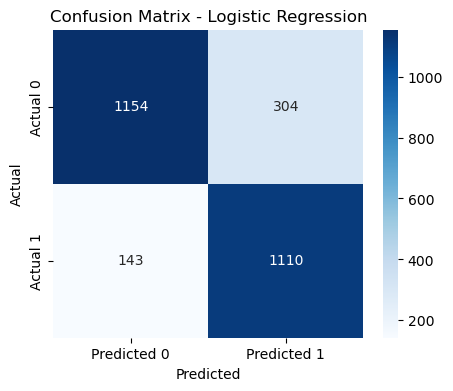

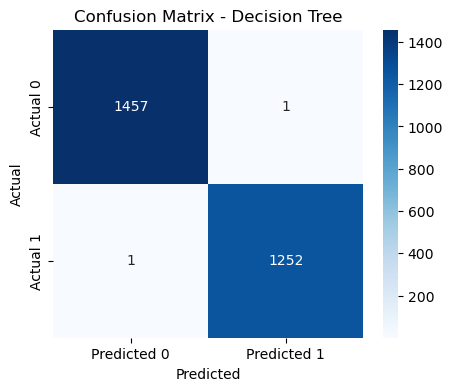

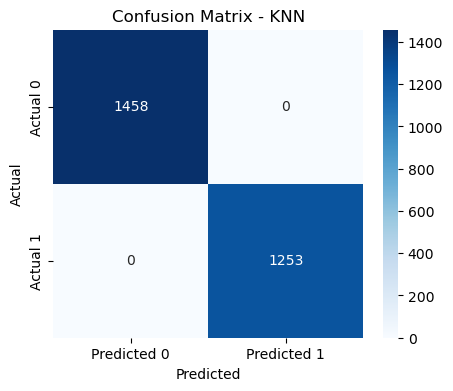

In [22]:
for name, info in results.items():
    cm = confusion_matrix(y_test, info["predictions"])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )

    plt.title("Confusion Matrix - " + name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [23]:
# import joblib

# joblib.dump(results["Logistic Regression"]["model"],
#             "logistic_regression_model.pkl")

# joblib.dump(results["Decision Tree"]["model"],
#             "decision_tree_model.pkl")

# joblib.dump(results["KNN"]["model"],
#             "knn_model.pkl")

In [24]:
# Original X_test data
prediction_df = X_test.copy()

# Actual target
prediction_df["Original"] = y_test

# Predictions of all models
prediction_df["Logistic Regression"] = results["Logistic Regression"]["predictions"]
prediction_df["Decision Tree"] = results["Decision Tree"]["predictions"]
prediction_df["KNN"] = results["KNN"]["predictions"]

# First 10 rows
prediction_df.head(30)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Original,Logistic Regression,Decision Tree,KNN
11809,57,0,1,131,235,0,0,174,0,0.00,1,1,2,0,1,0,0
5746,58,0,0,100,248,0,0,122,0,1.01,1,0,2,1,1,1,1
235,51,0,2,130,255,0,0,149,0,0.52,2,0,2,1,1,1,1
3037,54,0,1,132,288,1,0,160,1,0.02,2,1,2,1,1,1,1
8402,56,0,0,200,290,1,0,133,1,3.98,0,2,3,0,0,0,0
6143,63,0,2,135,252,0,0,172,0,0.01,2,0,2,1,1,1,1
7452,49,0,0,131,270,0,1,163,0,0.02,2,0,2,1,1,1,1
308,51,1,2,110,176,0,1,123,0,0.64,2,0,2,1,1,1,1
10783,54,1,0,140,239,0,1,159,0,1.19,2,0,2,1,1,1,1
9120,59,1,1,140,222,0,1,165,1,-0.01,2,0,2,1,1,1,1
